<a href="https://colab.research.google.com/github/AytenHarman07/AytenHarman07/blob/main/Statistical_Analysis_of_Prostate_Cancer_Cell_Migration_(LNCaP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ANOVA P-değeri: 2.1029611913089462e-20

Gruplar arasında istatistiksel olarak anlamlı fark var! Tukey testine geçiyorum:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2 meandiff p-adj  lower    upper  reject
-----------------------------------------------------
 60_uM   80_uM    -10.0   0.0 -10.7664 -9.2336   True
 60_uM Kontrol    31.58   0.0  30.8136 32.3464   True
 80_uM Kontrol    41.58   0.0  40.8136 42.3464   True
-----------------------------------------------------


/tmp/ipykernel_4476/712330267.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grup', y='Migrasyon_Orani', data=df, palette="Set2")


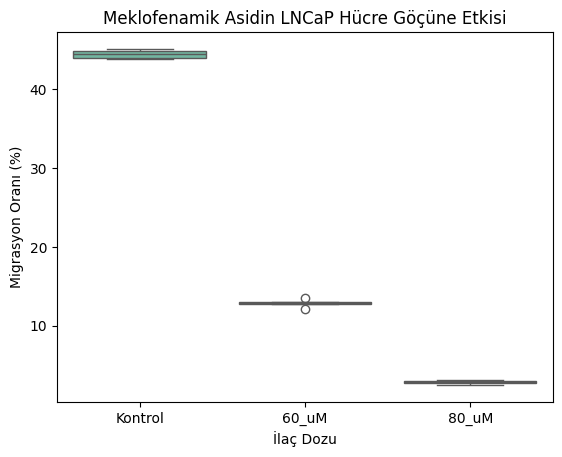

In [1]:
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. VERİYİ HAZIRLAMA
# Laboratuvarda LNCaP kanser hücrelerine verdiğimiz ilaç dozları.
# Şimdilik verileri kodun içine elle giriyorum, ileride bunu bir excel'den okutacağım :)
veri = {
    'Grup': ['Kontrol', 'Kontrol', 'Kontrol', 'Kontrol', 'Kontrol',
             '60_uM', '60_uM', '60_uM', '60_uM', '60_uM',
             '80_uM', '80_uM', '80_uM', '80_uM', '80_uM'],

    # Hücrelerin göç etme oranları (%)
    'Migrasyon_Orani': [44.4, 45.1, 43.8, 44.9, 44.0,
                        12.9, 13.5, 12.1, 13.0, 12.8,
                        2.9, 3.1, 2.5, 3.0, 2.8]
}

# Veriyi Pandas ile bir tabloya (DataFrame) dönüştürelim
df = pd.DataFrame(veri)

# 2. ANOVA TESTİ
# Acaba bu üç doz grubu arasında gerçekten istatistiksel bir fark var mı?
kontrol = df[df['Grup'] == 'Kontrol']['Migrasyon_Orani']
doz_60 = df[df['Grup'] == '60_uM']['Migrasyon_Orani']
doz_80 = df[df['Grup'] == '80_uM']['Migrasyon_Orani']

# Tek yönlü (One-Way) ANOVA yapıyoruz
f_degeri, p_degeri = stats.f_oneway(kontrol, doz_60, doz_80)

print(f"ANOVA P-değeri: {p_degeri}")

# 3. TUKEY HSD TESTİ
# Eğer P değeri 0.05'ten küçükse "anlamlı bir fark var" demektir.
# O zaman hangi ilacın hangi grupta fark yarattığını bulmak için Tukey testine geçiyorum.
if p_degeri < 0.05:
    print("\nGruplar arasında istatistiksel olarak anlamlı fark var! Tukey testine geçiyorum:")
    tukey_sonucu = pairwise_tukeyhsd(endog=df['Migrasyon_Orani'], groups=df['Grup'], alpha=0.05)
    print(tukey_sonucu)
else:
    print("\nGruplar arasında anlamlı bir fark yok.")

# 4. GÖRSELLEŞTİRME
# Makalelerde veya laboratuvar sunumlarında kullanmak için Seaborn ile basit bir grafik çiziyorum.
sns.boxplot(x='Grup', y='Migrasyon_Orani', data=df, palette="Set2")

plt.title("Meklofenamik Asidin LNCaP Hücre Göçüne Etkisi")
plt.xlabel("İlaç Dozu")
plt.ylabel("Migrasyon Oranı (%)")

# Çizdiğim grafiği bilgisayara kaydediyorum
plt.savefig("migrasyon_kutugrafigi.png", dpi=300)
plt.show()